In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")


In [8]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "assets" / "data"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# from matplotlib.pyplot import spring
# from matplotlib.pyplot import summer
# from matplotlib.pyplot import autumn
# from matplotlib.pyplot import winter

# spring = pd.read_csv(
#     "../assets/data/photovoltaic_spiring_2022_2023.csv"
# )
# summer = pd.read_csv(
#     "../assets/data/Photovoltaic summer 2022-2023.csv"
# )
# autumn = pd.read_csv(
#     "../assets/data/Photovoltaic autumn 2022-2023.csv"
# )
# winter = pd.read_csv(
#     "../assets/data/Photovoltaic winter 2022-2023.csv"
# )

# print(type(spring))
# print(type(summer))
# print(type(autumn))
# print(type(winter))

# datasets = {
#     "Spring": spring,
#     "Summer": summer,
#     "Autumn": autumn,
#     "Winter": winter
# }

# missing_summary = []

# for dataset_name, dataframe in datasets.items():
#     total_missing = dataframe.isnull().sum().sum()
#     total_values = dataframe.shape[0] * dataframe.shape[1]
#     missing_rate = (total_missing / total_values) * 100

#     missing_summary.append({
#         "Dataset": dataset_name,
#         "Rows": dataframe.shape[0],
#         "Columns": dataframe.shape[1],
#         "Total Missing": total_missing,
#         "Missing Rate (%)": missing_rate
#     })

# missing_summary = pd.DataFrame(missing_summary)

# missing_summary["Missing Rate (%)"] = (
#     missing_summary["Missing Rate (%)"].round(2)
# )

# missing_summary

# # Check rows containing missing values

# for dataset_name, dataframe in datasets.items():
#     missing_rows = dataframe.isnull().any(axis=1).sum()
#     missing_row_rate = (missing_rows / len(dataframe)) * 100

#     print(
#         f"{dataset_name}: "
#         f"{missing_rows} rows "
#         f"({missing_row_rate:.2f}%) contain missing values"
#     )

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
Spring: 887 rows (3.95%) contain missing values
Summer: 1341 rows (5.48%) contain missing values
Autumn: 947 rows (3.82%) contain missing values
Winter: 4354 rows (19.63%) contain missing values


In [13]:
file_path = RAW_DATA_DIR / "photovoltaic_spiring_2022_2023.csv"

spring = pd.read_csv(file_path)

print(f"Number of rows: {spring.shape[0]:,}")
print(f"Number of columns: {spring.shape[1]:,}")

spring.tail()
spring.columns.tolist()
spring.info()

dtype_summary = pd.DataFrame({
    "Column": spring.columns,
    "Data_Type": spring.dtypes.astype(str).values,
    "Non_Null_Count": spring.notna().sum().values,
    "Missing_Count": spring.isna().sum().values
})

display(dtype_summary)

Number of rows: 22,464
Number of columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22464 entries, 0 to 22463
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    22464 non-null  float64
 1   Active_Power                 22461 non-null  float64
 2   Wind_Speed                   21580 non-null  float64
 3   Weather_Temperature_Celsius  21580 non-null  float64
 4   Global_Horizontal_Radiation  21580 non-null  float64
 5   Wind_Direction               21580 non-null  float64
 6   Weather_Daily_Rainfall       21580 non-null  float64
 7   Max_Wind_Speed               21580 non-null  float64
 8   Air_Pressure                 21580 non-null  float64
 9   Hail_Accumulation            21580 non-null  float64
dtypes: float64(10)
memory usage: 1.7 MB


,Column,Data_Type,Non_Null_Count,Missing_Count
0,timestamp,float64,22464,0
1,Active_Power,float64,22461,3
2,Wind_Speed,float64,21580,884
3,Weather_Temperature_Celsius,float64,21580,884
4,Global_Horizontal_Radiation,float64,21580,884
5,Wind_Direction,float64,21580,884
6,Weather_Daily_Rainfall,float64,21580,884
7,Max_Wind_Speed,float64,21580,884
8,Air_Pressure,float64,21580,884
9,Hail_Accumulation,float64,21580,884


In [44]:
# Timestamp Analysis
spring["datetime"] = pd.to_datetime(
    spring["timestamp"],
    unit="D",
    origin="1899-12-30"
)

spring["datetime"] = spring["datetime"].dt.round("min")

print("Start:", spring["datetime"].min())
print("End:", spring["datetime"].max())

Start: 2022-12-01 00:00:00
End: 2023-02-28 23:55:00


In [45]:
# Sampling Interval
time_difference = spring["datetime"].diff().dropna()

display(time_difference.describe())

sampling_interval = (
    time_difference
    .dt.total_seconds()
    .div(60)
    .round(3)
    .value_counts()
    .sort_index()
)

display(sampling_interval.head(20))


# Gap
large_gaps = spring.loc[
    spring["datetime"].diff() > pd.Timedelta(minutes=10),
    ["datetime"]
].copy()

large_gaps["gap"] = spring["datetime"].diff()[
    spring["datetime"].diff() > pd.Timedelta(minutes=10)
]

display(large_gaps.head(20))

count                        22463
mean     0 days 00:05:46.155900814
std      0 days 01:46:07.339930328
min                0 days 00:05:00
25%                0 days 00:05:00
50%                0 days 00:05:00
75%                0 days 00:05:00
max               11 days 00:05:00
Name: datetime, dtype: object

datetime
5.0        22461
1445.0         1
15845.0        1
Name: count, dtype: int64

,datetime,gap
8352,2023-01-10,11 days 00:05:00
20448,2023-02-22,1 days 00:05:00


In [46]:
# Missing Value Analysis
missing_summary = pd.DataFrame({
    "Missing_Count": spring.isna().sum(),
    "Missing_Percentage": spring.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing_Count",
    ascending=False
)

display(missing_summary)

weather_columns = [
    "Wind_Speed",
    "Weather_Temperature_Celsius",
    "Global_Horizontal_Radiation",
    "Wind_Direction",
    "Weather_Daily_Rainfall",
    "Max_Wind_Speed",
    "Air_Pressure",
    "Hail_Accumulation"
]

weather_missing_mask = spring[weather_columns].isna().all(axis=1)

print(
    "Rows where all weather variables are missing:",
    weather_missing_mask.sum()
)

display(
    spring.loc[
        weather_missing_mask,
        ["datetime"] + weather_columns
    ].head(20)
)

,Missing_Count,Missing_Percentage
Wind_Speed,884,3.935185
Weather_Temperature_Celsius,884,3.935185
Global_Horizontal_Radiation,884,3.935185
Wind_Direction,884,3.935185
Weather_Daily_Rainfall,884,3.935185
Max_Wind_Speed,884,3.935185
Air_Pressure,884,3.935185
Hail_Accumulation,884,3.935185
Active_Power,3,0.013355
timestamp,0,0.000000


Rows where all weather variables are missing: 884


,datetime,Wind_Speed,Weather_Temperature_Celsius,Global_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Max_Wind_Speed,Air_Pressure,Hail_Accumulation
54,2022-12-01 04:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,2022-12-01 10:25:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144,2022-12-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323,2022-12-02 02:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324,2022-12-02 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
328,2022-12-02 03:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
329,2022-12-02 03:25:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
330,2022-12-02 03:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
331,2022-12-02 03:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
332,2022-12-02 03:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Duplicate Check
duplicate_count = spring.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")


Duplicate rows: 0


In [29]:
# Descriptive Statistic
descriptive_statistics = spring.describe().T

display(descriptive_statistics)

suspicious_columns = [
    "Weather_Daily_Rainfall",
    "Hail_Accumulation"
]

for column in suspicious_columns:
    print(f"\n----- {column} -----")
    print(
        spring[column]
        .sort_values()
        .head(10)
        .to_list()
    )

spring["Weather_Daily_Rainfall"].value_counts(dropna=False).head(10)
spring["Hail_Accumulation"].value_counts(dropna=False).head(10)

,count,mean,min,25%,50%,75%,max,std
timestamp,22464.0,44941.998264,44896.0,44915.499133,44945.998265,44965.497397,44985.99653,27.255811
Active_Power,22461.0,341.412814,-0.478085,-0.36649,58.503207,734.375818,1431.940388,420.339736
Wind_Speed,21580.0,1.899092,0.07,1.106667,1.83,2.563333,8.64,1.013354
Weather_Temperature_Celsius,21580.0,29.541044,14.3,25.2025,29.5,34.116666,42.91,5.738063
Global_Horizontal_Radiation,21580.0,305.992575,-10.360827,-3.054134,51.710649,611.800873,1381.896606,398.154636
Wind_Direction,21580.0,156.788074,24.4,121.466667,144.966659,185.274998,351.433319,54.838311
Weather_Daily_Rainfall,21580.0,-13901.759267,-299999968.0,0.0,0.0,0.0,0.141667,2042186.910448
Max_Wind_Speed,21580.0,3.827994,0.2,2.2,3.7,5.2,15.2,2.042971
Air_Pressure,21580.0,951.106623,945.083313,949.533325,951.003357,952.62413,957.380005,2.219032
Hail_Accumulation,21580.0,-13901.759407,-299999968.0,0.0,0.0,0.0,0.0,2042186.910447



----- Weather_Daily_Rainfall -----
[-299999968.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

----- Hail_Accumulation -----
[-299999968.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


count    22461.000000
mean       341.412814
std        420.339736
min         -0.478085
25%         -0.366490
50%         58.503207
75%        734.375818
max       1431.940388
Name: Active_Power, dtype: float64

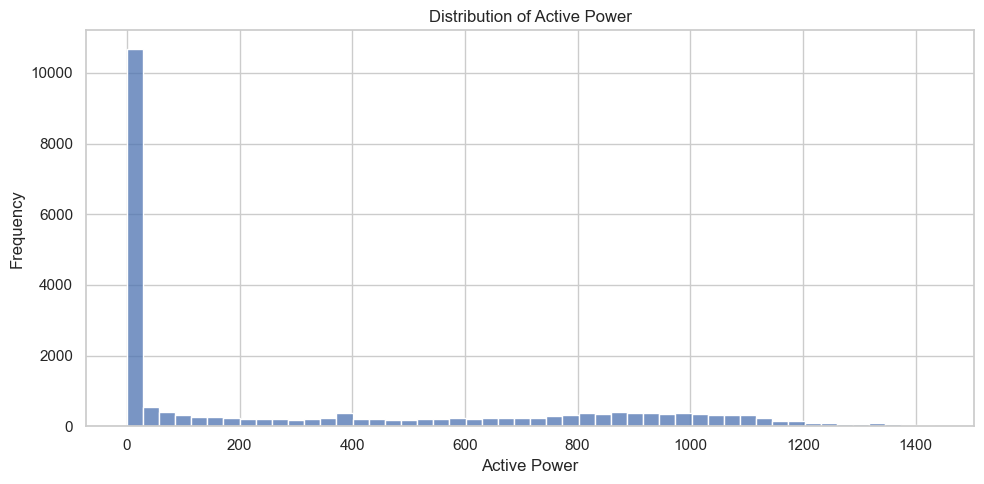

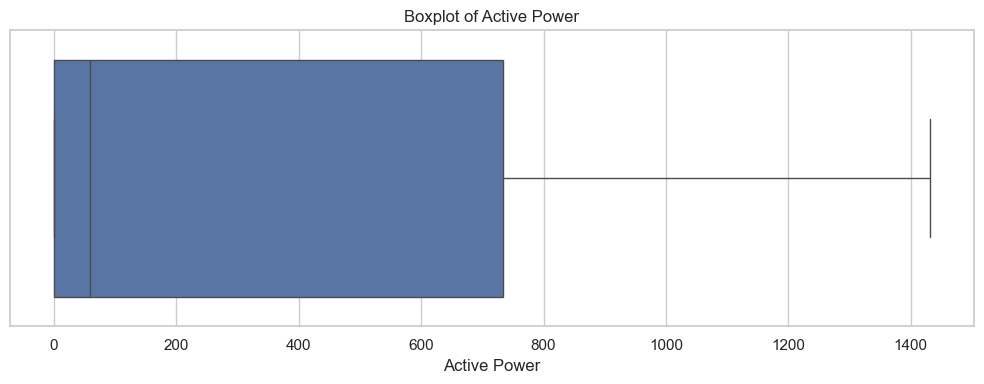

In [32]:
# Investigasi Active Power
spring["Active_Power"].describe()

plt.figure(figsize=(10, 5))

sns.histplot(
    data=spring,
    x="Active_Power",
    bins=50
)

# Distribusi of Active Power
plt.title("Distribution of Active Power")
plt.xlabel("Active Power")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=spring["Active_Power"]
)

# Boxplot Active Power
plt.title("Boxplot of Active Power")
plt.xlabel("Active Power")

plt.tight_layout()
plt.show()

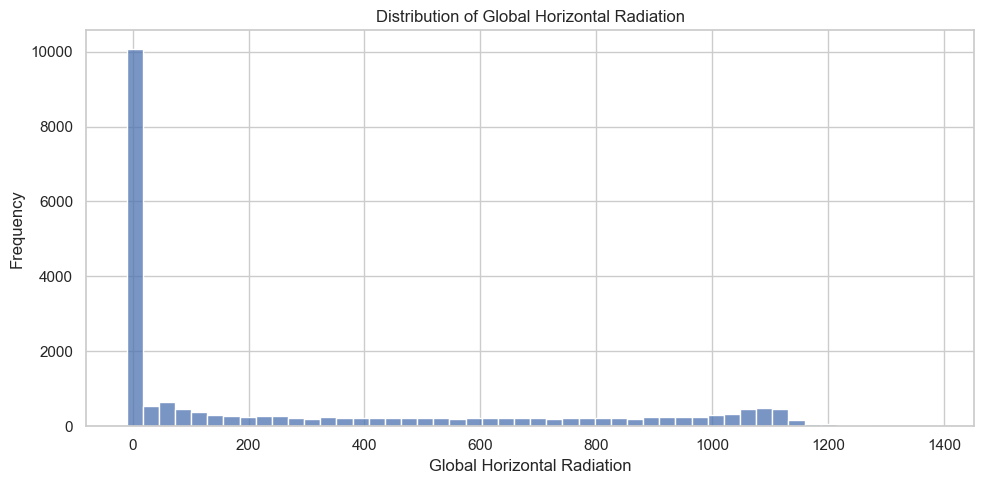

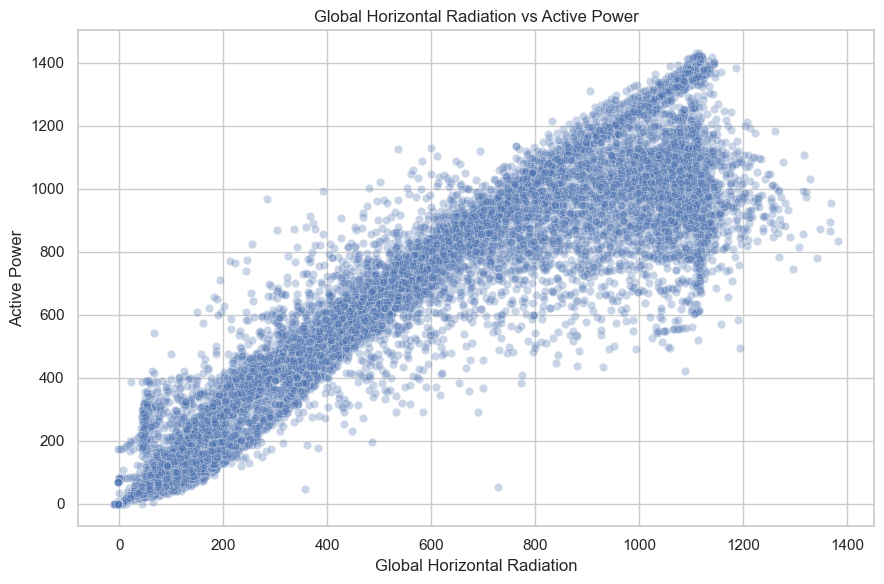

In [35]:
# Global Horizontal Radiation
plt.figure(figsize=(10, 5))

sns.histplot(
    data=spring,
    x="Global_Horizontal_Radiation",
    bins=50
)

plt.title("Distribution of Global Horizontal Radiation")
plt.xlabel("Global Horizontal Radiation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Conect to Power
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=spring,
    x="Global_Horizontal_Radiation",
    y="Active_Power",
    alpha=0.3
)

plt.title(
    "Global Horizontal Radiation vs Active Power"
)

plt.xlabel("Global Horizontal Radiation")
plt.ylabel("Active Power")

plt.tight_layout()
plt.show()

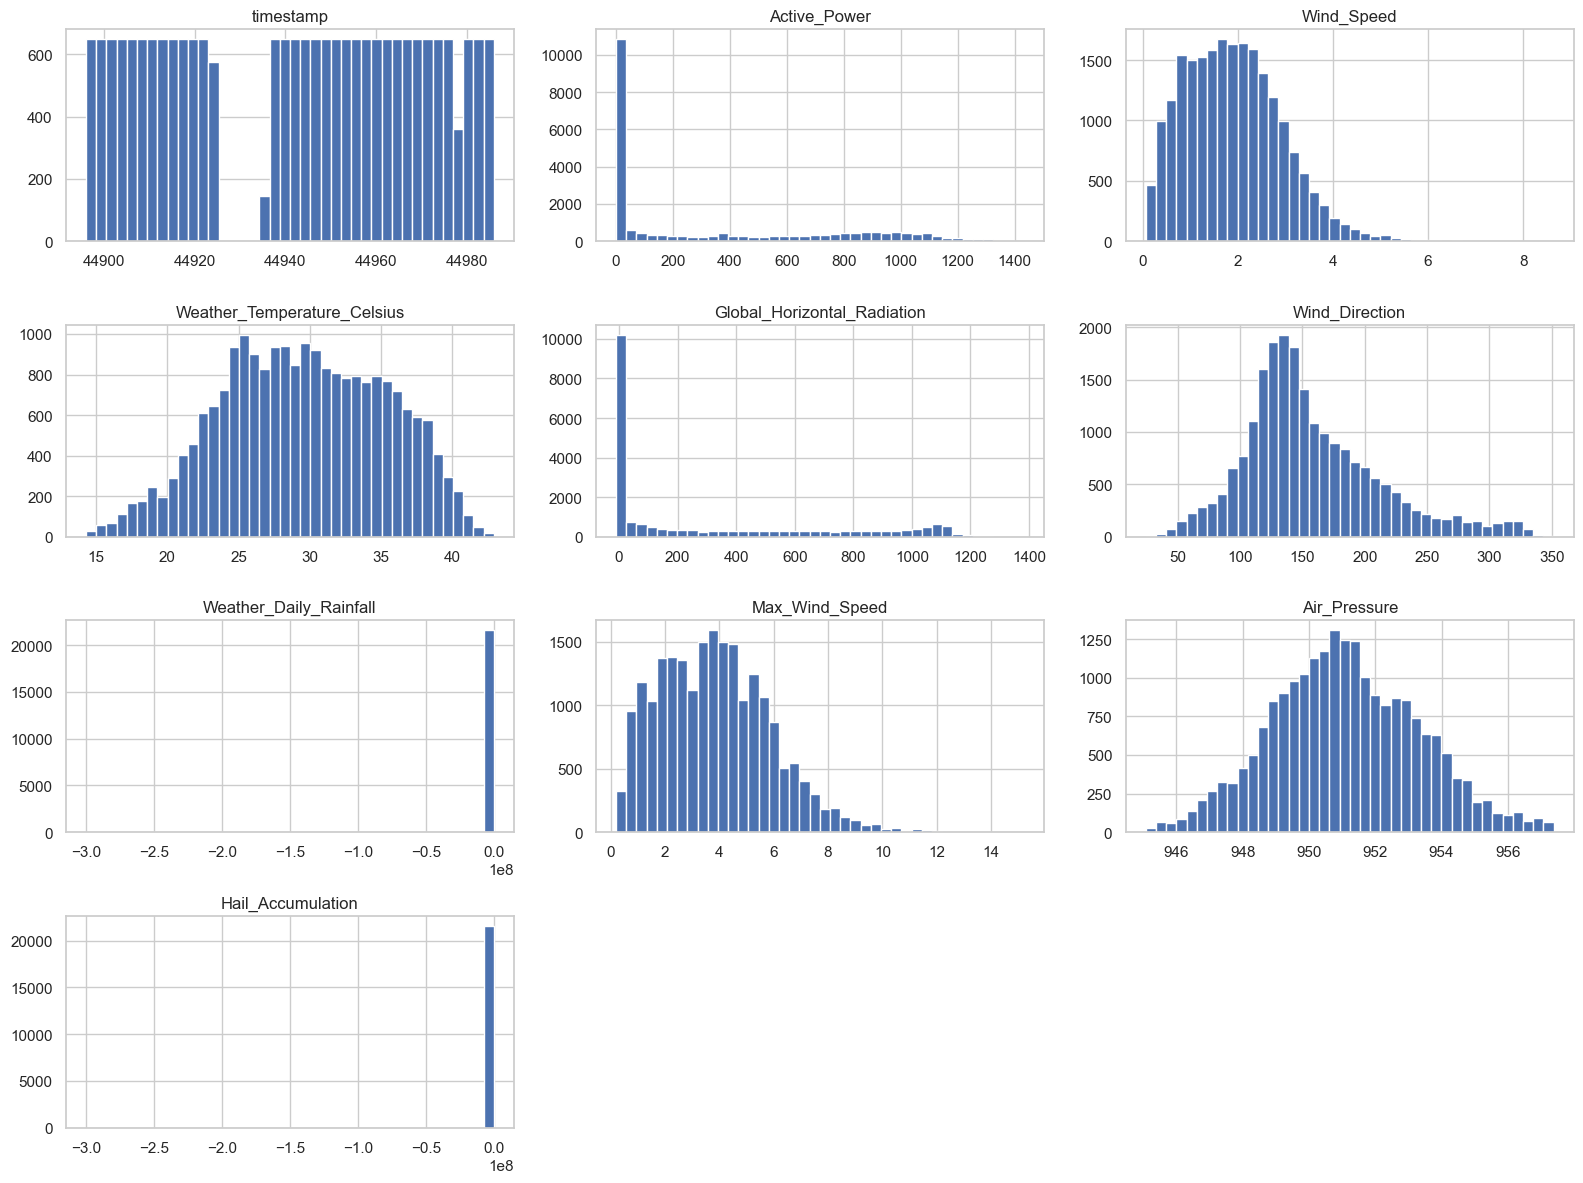

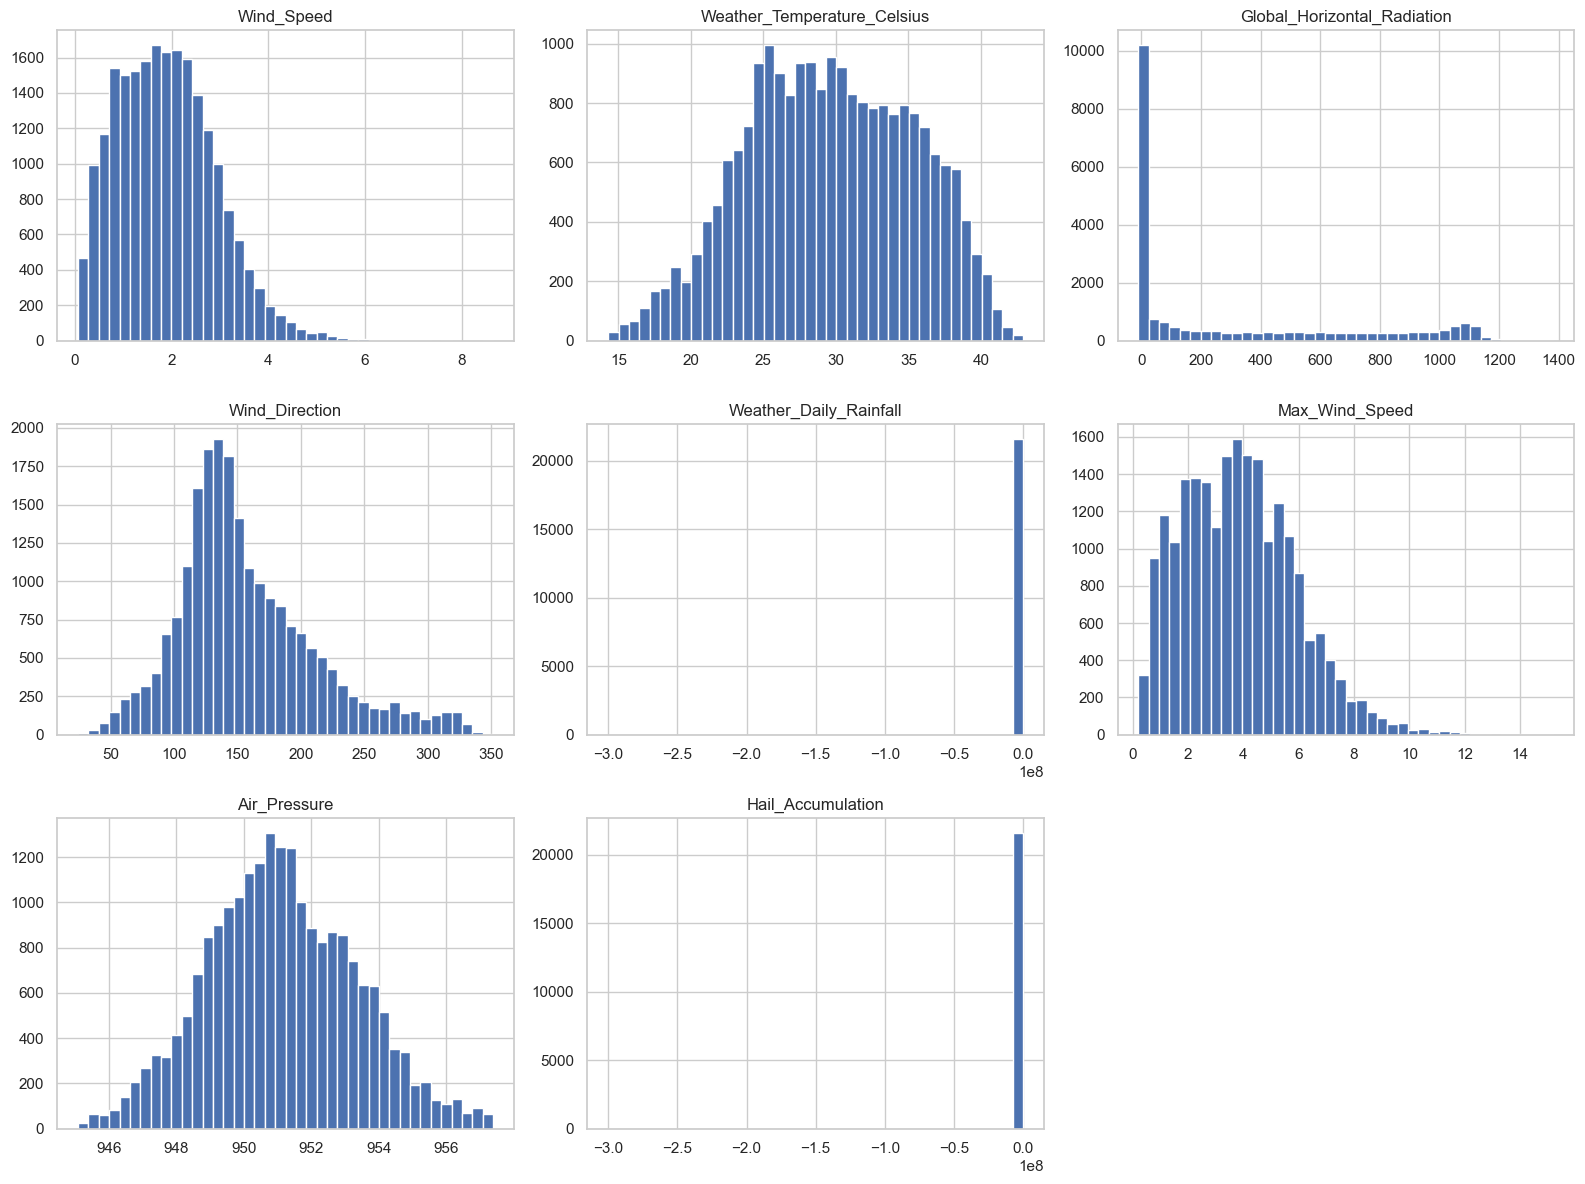

In [37]:
# Feature Analysis
numeric_columns = spring.select_dtypes(
    include=np.number
).columns

spring[numeric_columns].hist(
    figsize=(16, 12),
    bins=40
)

plt.tight_layout()
plt.show()

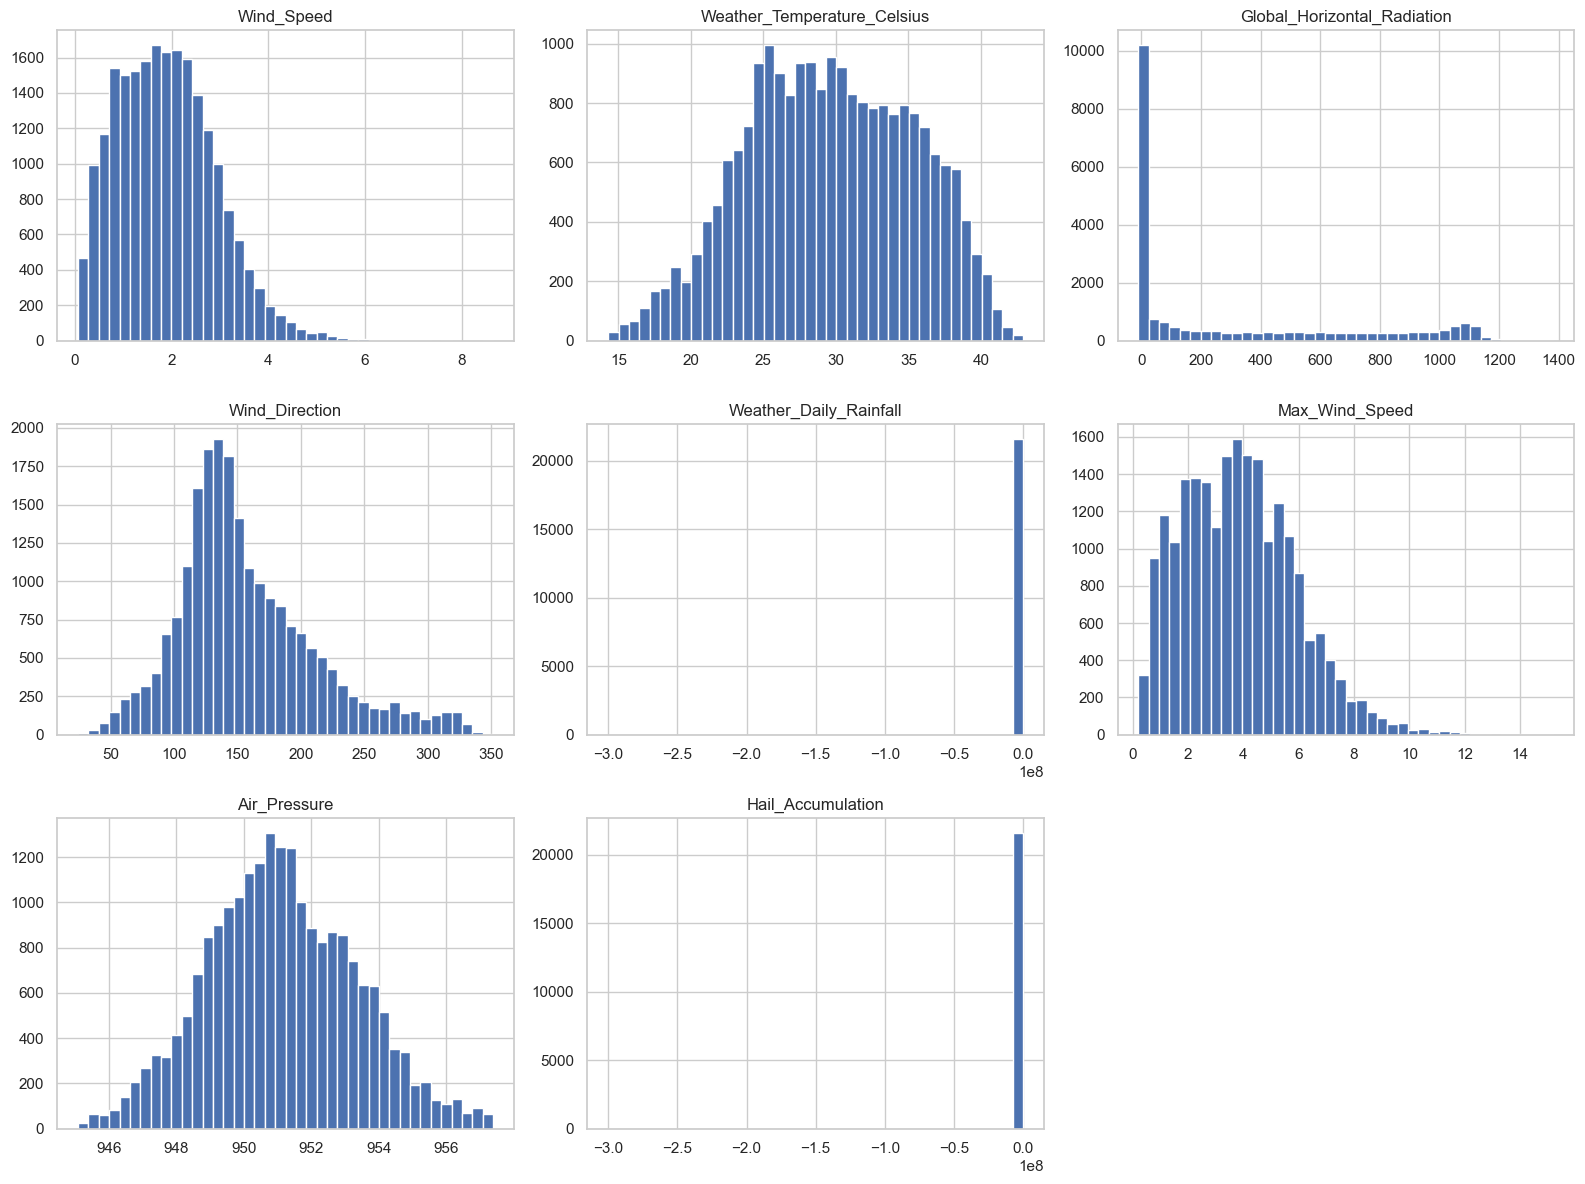

In [38]:
feature_columns = [
    "Wind_Speed",
    "Weather_Temperature_Celsius",
    "Global_Horizontal_Radiation",
    "Wind_Direction",
    "Weather_Daily_Rainfall",
    "Max_Wind_Speed",
    "Air_Pressure",
    "Hail_Accumulation"
]

spring[feature_columns].hist(
    figsize=(16, 12),
    bins=40
)

plt.tight_layout()
plt.show()

,Active_Power,Wind_Speed,Weather_Temperature_Celsius,Global_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Max_Wind_Speed,Air_Pressure,Hail_Accumulation
Active_Power,1.000000,0.394694,0.501723,0.962769,-0.146104,-0.036387,0.446087,0.053016,NaN
Wind_Speed,0.394694,1.000000,0.225579,0.382912,0.027602,0.021649,0.953169,0.088397,NaN
Weather_Temperature_Celsius,0.501723,0.225579,1.000000,0.492230,-0.077468,-0.077596,0.274925,-0.459880,NaN
Global_Horizontal_Radiation,0.962769,0.382912,0.492230,1.000000,-0.146274,-0.040618,0.436393,0.042405,NaN
Wind_Direction,-0.146104,0.027602,-0.077468,-0.146274,1.000000,0.002861,-0.004334,-0.218146,NaN
Weather_Daily_Rainfall,-0.036387,0.021649,-0.077596,-0.040618,0.002861,1.000000,0.022255,-0.000556,NaN
Max_Wind_Speed,0.446087,0.953169,0.274925,0.436393,-0.004334,0.022255,1.000000,0.076821,NaN
Air_Pressure,0.053016,0.088397,-0.459880,0.042405,-0.218146,-0.000556,0.076821,1.000000,NaN
Hail_Accumulation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


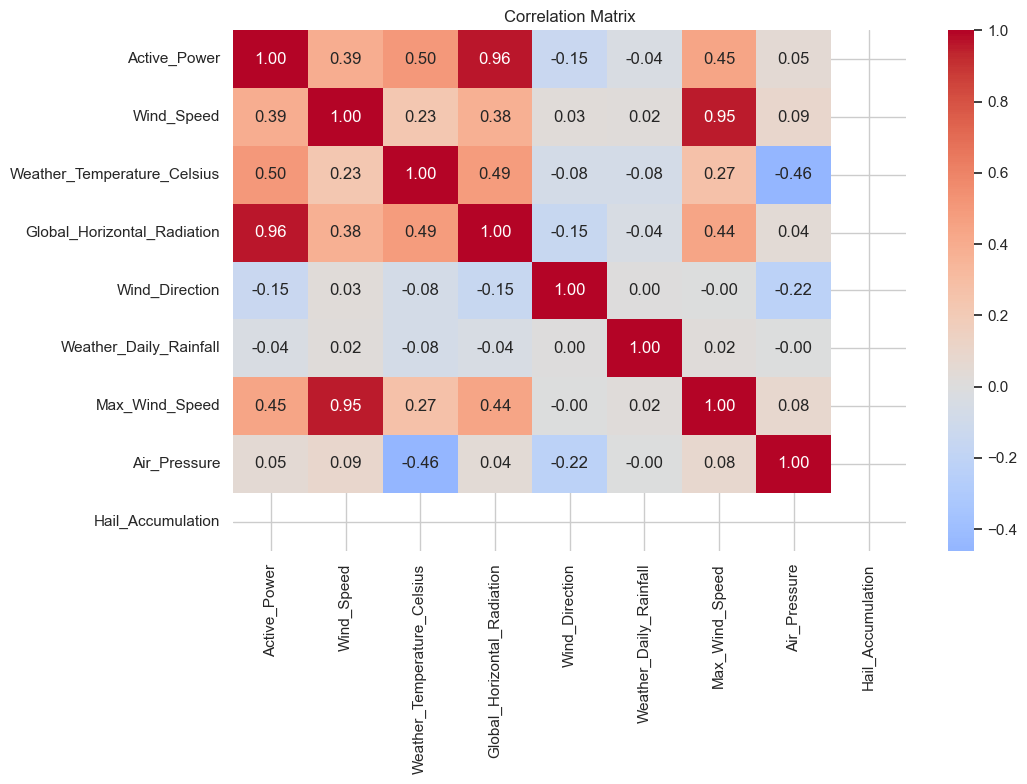

In [41]:
eda_data = spring.copy()

sentinel_values = [-299999968]

eda_data = eda_data.replace(
    sentinel_values,
    np.nan
)

correlation_matrix = eda_data[
    ["Active_Power"] + feature_columns
].corr()

display(correlation_matrix)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [42]:
target_correlation = (
    correlation_matrix["Active_Power"]
    .drop("Active_Power")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(target_correlation)

Global_Horizontal_Radiation    0.962769
Weather_Temperature_Celsius    0.501723
Max_Wind_Speed                 0.446087
Wind_Speed                     0.394694
Wind_Direction                -0.146104
Air_Pressure                   0.053016
Weather_Daily_Rainfall        -0.036387
Hail_Accumulation                   NaN
Name: Active_Power, dtype: float64

In [43]:
missing_weather = spring.loc[
    spring[weather_columns].isna().any(axis=1),
    ["datetime"] + weather_columns
].copy()

display(missing_weather.head())

print("First missing weather timestamp:")
print(missing_weather["datetime"].min())

print("\nLast missing weather timestamp:")
print(missing_weather["datetime"].max())

missing_by_date = (
    spring.assign(
        date=spring["datetime"].dt.date,
        weather_missing=spring[weather_columns].isna().any(axis=1)
    )
    .groupby("date")["weather_missing"]
    .sum()
)

display(
    missing_by_date[missing_by_date > 0]
)

,datetime,Wind_Speed,Weather_Temperature_Celsius,Global_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Max_Wind_Speed,Air_Pressure,Hail_Accumulation
54,2022-12-01 04:30:00.000000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,2022-12-01 10:25:00.191999714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144,2022-12-01 12:00:00.000000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323,2022-12-02 02:55:00.191999714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324,2022-12-02 03:00:00.000000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


First missing weather timestamp:
2022-12-01 04:30:00

Last missing weather timestamp:
2023-02-28 19:50:00.096000172


date
2022-12-01      3
2022-12-02     28
2022-12-03      3
2022-12-04      1
2022-12-06      2
2022-12-08      8
2022-12-09     38
2022-12-10      1
2022-12-13      4
2022-12-15      1
2022-12-18     86
2022-12-19    116
2022-12-22     31
2022-12-25      1
2022-12-26      3
2022-12-28      6
2022-12-29     18
2023-01-10      1
2023-01-11      2
2023-01-14      7
2023-01-15     16
2023-01-16      4
2023-01-18      1
2023-01-19      1
2023-01-21      9
2023-01-22      1
2023-01-24      7
2023-01-25     21
2023-01-26      4
2023-01-27      2
2023-02-01     16
2023-02-02     32
2023-02-03     45
2023-02-04      5
2023-02-05     56
2023-02-06     22
2023-02-07     21
2023-02-08     32
2023-02-09      6
2023-02-10      4
2023-02-11     38
2023-02-12      2
2023-02-13      1
2023-02-15     18
2023-02-16      5
2023-02-17      9
2023-02-18      7
2023-02-19      8
2023-02-20      3
2023-02-22     10
2023-02-23     51
2023-02-24     44
2023-02-25     10
2023-02-26      1
2023-02-27     11
2023-